In [2]:
def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 33
bound = 5
output = elliptic_fourier_expansions(level, bound)
print(len(output))
print()
print(output)
print()
print(output[0])
print()
print(output[0][1])

1

[('33a1', [(1, 1), (2, 1), (3, -1), (4, -1), (5, -2)])]

('33a1', [(1, 1), (2, 1), (3, -1), (4, -1), (5, -2)])

[(1, 1), (2, 1), (3, -1), (4, -1), (5, -2)]


In [3]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 33
bound =2800
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print("label:", label)
coeffs_list=[pair[1] for pair in expansion]

    
h_list=[1]+coeffs_list # h_0 = 1 required by the lemmas
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,501):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    print((n,j_n))
    j_list.append((n,j_n))

with open('/Users/barrybrent/data2/run1apr26no11.txt', 'wb') as wfile:
    pickle.dump(expansion, wfile) 
    
with open('/Users/barrybrent/data2/run1apr26no12.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

label: 33a1
(1, 1)
(2, 1)
(3, -5)
(4, 1)
(5, -4)
(6, -5)
(7, 36)
(8, -71)
(9, 31)
(10, 66)
(11, -153)
(12, 151)
(13, -38)
(14, -300)
(15, 920)
(16, -1159)
(17, 18)
(18, 2461)
(19, -4388)
(20, 3386)
(21, 2256)
(22, -12561)
(23, 22242)
(24, -16121)
(25, -19879)
(26, 75362)
(27, -102029)
(28, 37276)
(29, 147118)
(30, -384990)
(31, 461498)
(32, -61191)
(33, -939471)
(34, 2025330)
(35, -1929064)
(36, -658415)
(37, 5610940)
(38, -9883628)
(39, 7450906)
(40, 7263314)
(41, -31677542)
(42, 47532564)
(43, -24225640)
(44, -58108577)
(45, 171407486)
(46, -215576860)
(47, 50257336)
(48, 384833927)
(49, -892645067)
(50, 935051591)
(51, 126733278)
(52, -2363054342)
(53, 4483107450)
(54, -3732461825)
(55, -2556234608)
(56, 13582933692)
(57, -21695909492)
(58, 13203697478)
(59, 22267199854)
(60, -74745865234)
(61, 100764922842)
(62, -35089059928)
(63, -156196227072)
(64, 394718469369)
(65, -445478808168)
(66, 10068985845)
(67, 984261335834)
(68, -2011187392222)
(69, 1843897505958)
(70, 808699980840)
(7

1 0.00015263160069783527
2 0.0008307854334513346
3 0.001209716002146403
4 0.0012691497802734375
5 0.0013005296389261881
6 0.0013293027877807617
7 0.0013736486434936523
8 0.0014235019683837891
9 0.0014750321706136068
10 0.0015429337819417319
11 0.0016080697377522787
12 0.001689600944519043
13 0.0017722487449645997
14 0.0018690188725789389
15 0.0020108501116434733
16 0.0021316170692443847
17 0.0022835135459899902
18 0.0024565855662027993
19 0.0026492834091186523
20 0.0028684139251708984
21 0.0031222025553385418
22 0.0033567309379577636
23 0.0035709182421366373
24 0.0038473804791768393
25 0.004166599114735921
26 0.004528915882110596
27 0.004892746607462565
28 0.005284468332926433
29 0.005688166618347168
30 0.0061569650967915855
31 0.006625564893086752
32 0.007244431972503662
33 0.007840331395467122
34 0.008479098478953043
35 0.009150302410125733
36 0.00995411475499471
37 0.010717936356862386
38 0.011490813891092936
39 0.012389429410298665
40 0.013382848103841145
41 0.014312664667765299
42

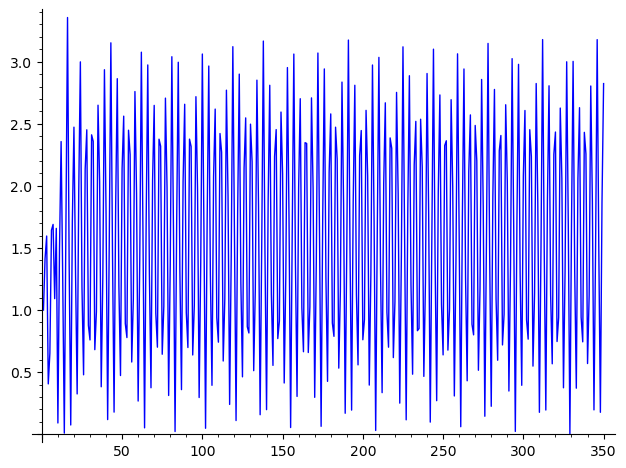

In [4]:
import pickle
from sage.all import sigma, nth_prime
import ast
import time

start=time.time()
with open('/Users/barrybrent/data2/run1apr26no12.txt', 'rb') as rfile:
    j_list = pickle.load(rfile)
    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable

charpol_list=[]
roots_list=[]

mins_list=[]
log_mins_list=[]

dets=[]

for n in range(1, 351):
    print(n, (time.time()-start)/60)
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run1apr26no13.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run1apr26no24.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run1apr26no15.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped
